In [29]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add measurement mcts python package to path
sys.path.append('../src/measurement_mcts')
from measurement_mcts.utils.utils import rotate

In [23]:
poly1 = np.array([[ 6.0986195, -4.41407983],
                  [ 6.34232329, -2.24208231],
                  [7.62900635, -2.21459394]])

poly2 = np.array([[10.93894644, -2.24829601],
                  [10.03498688, -0.09382046],
                  [13.20863997,  1.37513476]])

poly3 = np.array([[8.40489718, 5.55029717],
                  [8.4116534, 3.30492024],
                  [9.67020797, 3.22984164]])

poly4 = np.array([[ 4.41407983,  6.0986195],
                  [ 2.24208231,  6.34232329]])

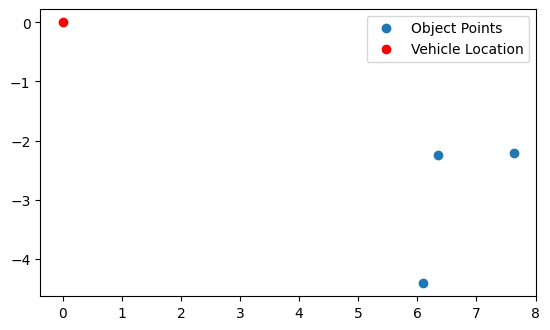

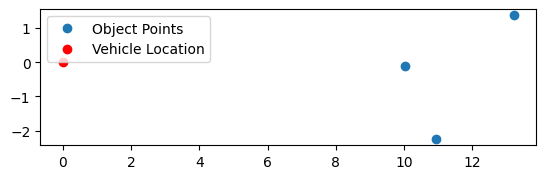

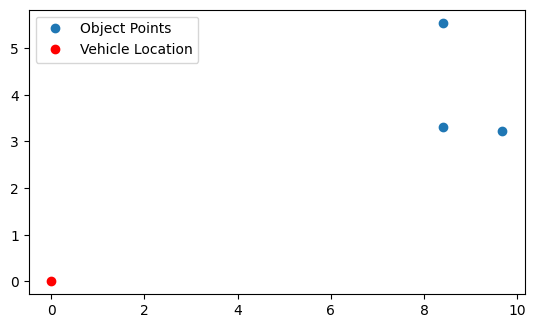

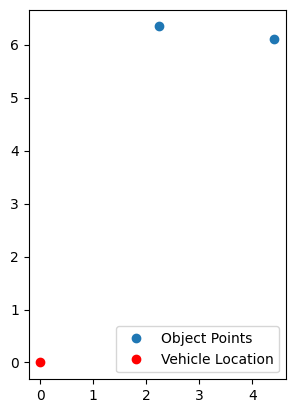

In [24]:
def plot_points(points, added_points=None, added_idx=None):
    fig, ax = plt.subplots()
    ax.set_aspect('equal')
    ax.plot(points[:,0], points[:,1], 'o', label='Object Points')
    ax.plot(0, 0, 'ro', label='Vehicle Location')
    if added_points is not None and added_idx is not None:
        ax.plot(added_points[added_idx,0], added_points[added_idx,1], 'o', label='Added Points')
    ax.legend()
    

plot_points(poly1)
plot_points(poly2)
plot_points(poly3)
plot_points(poly4)

In [28]:
v1 = np.array([1, 0.1])
v2 = np.array([1, -0.1])
v3 = np.array([-1, -0.2])

print(np.dot(v1, v2))
print(np.dot(v1, v3))

0.99
-1.02


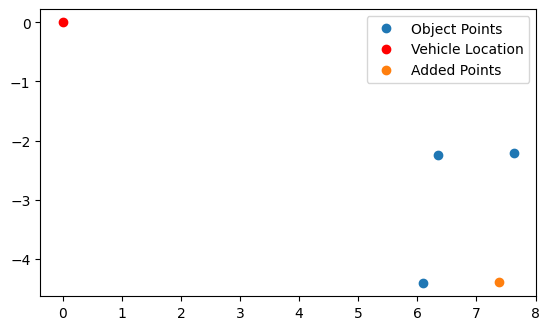

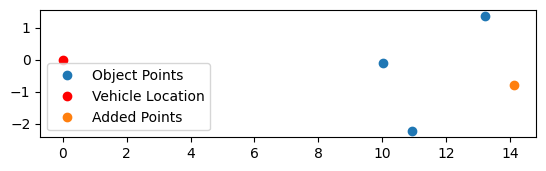

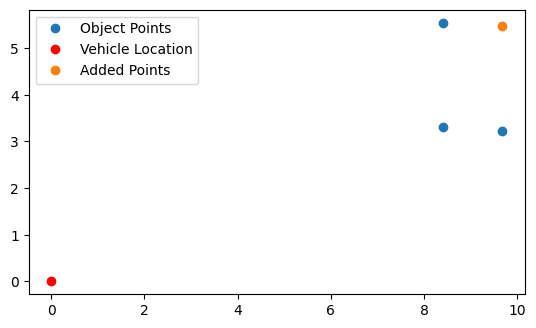

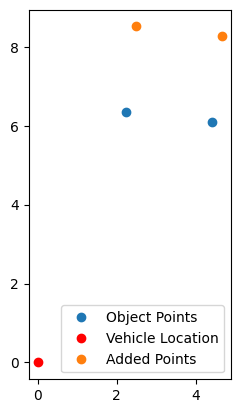

In [34]:
def estimate_remaining_points(points, vehicle_location=np.array([0, 0])):
    # If there are 3 points, we can estimate the fourth point by adding the two vectors from the intersection point to edges
    if points.shape[0] == 3:
        # Point 1 is the intersection point, point 0 and point 2 are the points at the ends of the plane
        final_point = (points[0]-points[1]) + (points[2] - points[1]) + points[1]
        
        # Return the original points and the index of the new point
        return np.vstack([points, final_point]), np.array([3])
    
    # For two points, we can assume that the object is a square and add the two points that are missing
    elif points.shape[0] == 2:
        # First take the vector between the two points
        between_points = points[1] - points[0]
        
        # Rotate the vector by +-90 degrees
        bp_plus, bp_minus = rotate(between_points, np.pi/2), rotate(between_points, -np.pi/2)
        
        # Find the vector from the vehicle to the first point, giving us the general direction of the object
        to_first_point = points[0] - vehicle_location
        
        # Calculate the dot product between the object direction and the two vectors after normalizing
        dot_plus = to_first_point/np.linalg.norm(to_first_point) @ bp_plus/np.linalg.norm(bp_plus)
        dot_minus = to_first_point/np.linalg.norm(to_first_point) @ bp_minus/np.linalg.norm(bp_minus)
        
        # Take the vector with the larger dot product which is the vector with the a similar direction as the object
        square_vector = bp_plus if dot_plus > dot_minus else bp_minus
        
        # Add the square vector to the two points to get the final points
        final_points = np.vstack([points, points[0] + square_vector, points[1] + square_vector])
        
        # Return the original points and the indices of the new points
        return final_points, np.array([2, 3])
        
filled_poly1, added_idx1 = estimate_remaining_points(poly1)
filled_poly2, added_idx2 = estimate_remaining_points(poly2)
filled_poly3, added_idx3 = estimate_remaining_points(poly3)
filled_poly4, added_idx4 = estimate_remaining_points(poly4)

plot_points(poly1, filled_poly1, added_idx1)
plot_points(poly2, filled_poly2, added_idx2)
plot_points(poly3, filled_poly3, added_idx3)
plot_points(poly4, filled_poly4, added_idx4)